In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve, confusion_matrix,
                             ConfusionMatrixDisplay)
from sklearn.inspection import permutation_importance
from utils import load_data, get_classification_split

TARGET = "CC50, mM"
THRESHOLD = None

# Классификация: CC50 > median

## Данные

In [2]:
df = load_data()
X_train, X_test, y_train, y_test = get_classification_split(df, TARGET, threshold=THRESHOLD)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print("Баланс классов (train):")
display(y_train.value_counts())

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

Train: (800, 192), Test: (201, 192)
Баланс классов (train):


CC50, mM
0    406
1    394
Name: count, dtype: int64

## Модели

In [3]:
models = {
    "LogisticRegression": LogisticRegression(C=1.0, max_iter=5000, random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42),
    "GradientBoosting": GradientBoostingClassifier(n_estimators=300, max_depth=5, learning_rate=0.1, random_state=42),
    "SVC": SVC(C=1.0, kernel="rbf", probability=True, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
}

results = []
fitted_models = {}

for name, model in models.items():
    use_scaled = name in ["LogisticRegression", "SVC", "KNN"]
    Xtr = X_train_sc if use_scaled else X_train
    Xte = X_test_sc if use_scaled else X_test

    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)
    y_proba = model.predict_proba(Xte)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "F1": round(f1_score(y_test, y_pred), 4),
        "ROC-AUC": round(roc_auc_score(y_test, y_proba), 4),
    })
    fitted_models[name] = (model, use_scaled)

results_df = pd.DataFrame(results).sort_values("F1", ascending=False)
results_df


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
1,RandomForest,0.8109,0.8602,0.7619,0.8081,0.8861
4,KNN,0.7861,0.8163,0.7619,0.7882,0.8526
3,SVC,0.7811,0.8081,0.7619,0.7843,0.8551
2,GradientBoosting,0.7861,0.8298,0.7429,0.7839,0.8659
0,LogisticRegression,0.7562,0.7745,0.7524,0.7633,0.8504


## ROC-кривые

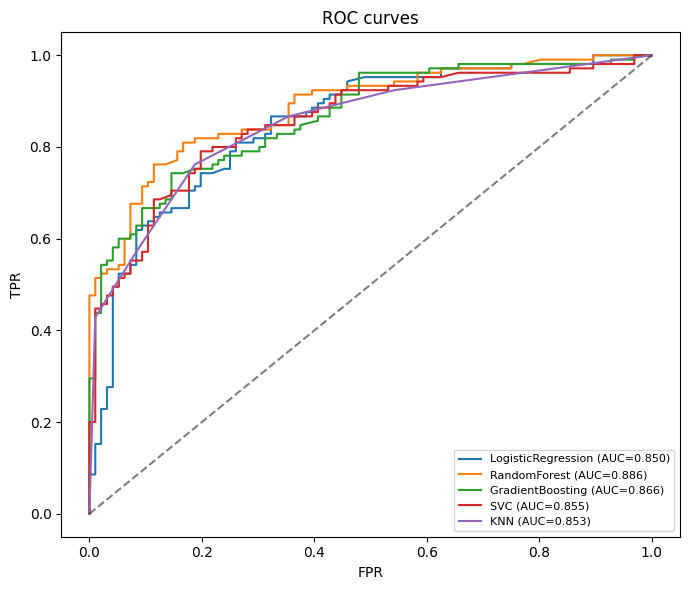

In [4]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, (model, use_scaled) in fitted_models.items():
    Xte = X_test_sc if use_scaled else X_test
    y_proba = model.predict_proba(Xte)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", alpha=0.5)
ax.set_xlabel("FPR")
ax.set_ylabel("TPR")
ax.set_title("ROC curves")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [5]:
tuned_clf = {}

rf_gs = GridSearchCV(
    RandomForestClassifier(random_state=42),
    {"n_estimators": [200, 400], "max_depth": [8, 12, None], "min_samples_leaf": [1, 3]},
    cv=5, scoring="f1", n_jobs=-1
)
rf_gs.fit(X_train, y_train)
tuned_clf["RandomForest"] = rf_gs.best_estimator_
print(f"RF: {rf_gs.best_params_}")

y_pred = tuned_clf["RandomForest"].predict(X_test)
y_proba = tuned_clf["RandomForest"].predict_proba(X_test)[:, 1]
print(f"F1={f1_score(y_test, y_pred):.4f}, ROC-AUC={roc_auc_score(y_test, y_proba):.4f}")


RF: {'max_depth': 8, 'min_samples_leaf': 1, 'n_estimators': 400}
F1=0.8079, ROC-AUC=0.8873


## Confusion matrix (лучшая модель)

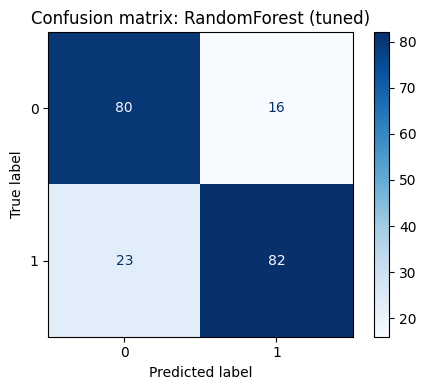

In [9]:
best_model = tuned_clf["RandomForest"]
y_pred = best_model.predict(X_test)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap="Blues")
ax.set_title("Confusion matrix: RandomForest (tuned)")
plt.tight_layout()
plt.show()


## Feature importance

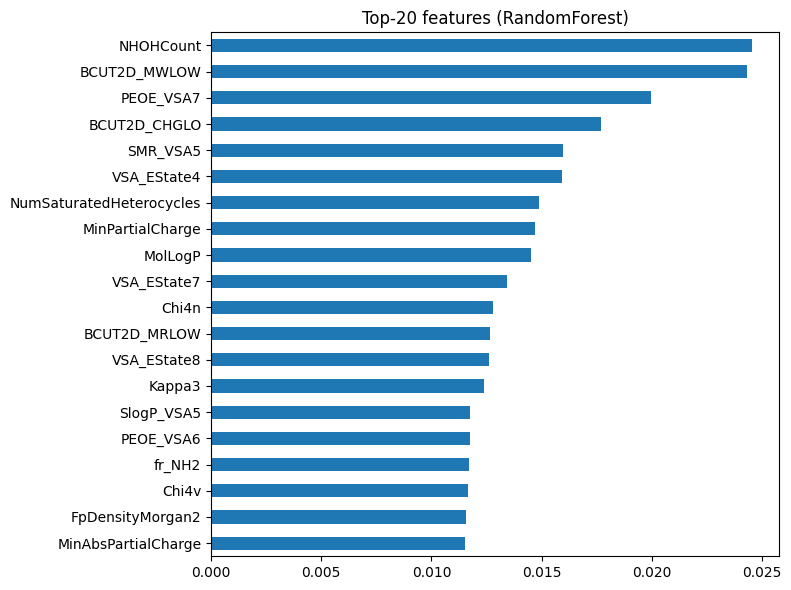

In [15]:
if hasattr(best_model, "feature_importances_"):
    feat_imp = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(20)
else:
    Xte = X_test_sc if use_scaled else X_test
    perm = permutation_importance(best_model, Xte, y_test, n_repeats=10, random_state=42, scoring="f1", n_jobs=-1)
    feat_imp = pd.Series(perm.importances_mean, index=X_train.columns).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(8, 6))
feat_imp.plot.barh(ax=ax)
ax.invert_yaxis()
ax.set_title("Top-20 features (RandomForest)")
plt.tight_layout()
plt.show()

## Выводы

Лучший результат среди всех задач - RF дает F1=0.81, AUC=0.89. CC50 в целом предсказывается лучше остальных таргетов, и регрессия это подтвердила. В топе признаков NHOHCount и BCUT2D_MWLOW, что связано с водородными связями и молекулярной массой.